# Example 3: Ruin Probability with Log-normal Claims
Here we consider a risk model with log-normal claim amounts.
The Laplace transform of a log-normal density has no known closed form, so we need approximations.


In [1]:
import sys
import os

# Add the parent directory to sys.path so we can import our src modules
sys.path.append(os.path.abspath('../'))

import mpmath, matplotlib.pyplot as plt
from tqdm import tqdm # for measuring progress

from src.talbot import talbot_method_abate
from src.laplace_transforms import lapl_psi, lapl_psi_1, lapl_psi_2, lapl_LN
from src.utils import print_results

In [2]:
# Set global precision
M = 60
ctx = mpmath.mp
ctx.dps = M

## Parameter Setup

In [3]:
mu_ln = ctx.mpf('1')    # mean of the normal
sigma_ln = ctx.mpf('1') # sd of the normal

mu = ctx.exp(mu_ln + sigma_ln**2 / 2)
c = ctx.mpf('2')
sigmasq = ctx.mpf('0.4')
lmbda = ctx.mpf('0.25')
# Other values
q = (c - lmbda * mu)/c
zeta = 2 * c / sigmasq

print(q > 0)

True


## Look for poles of lapl_psi
Assumption **(B1)** from the thesis is not obvious and verifying it analytically hard.

In [ ]:
# --- Search poles --- #
solutions = list()
# find solutions of F = 0
def F(s):
    return c * s + c / zeta * s ** 2 - lmbda + lmbda * lapl_LN(s, ctx, mu_N=mu_ln, sigma_N=sigma_ln)

# Grid of points in upper half plane
grid = [ctx.mpc(x, y) for x in ctx.linspace(-100, 5, 20) for y in ctx.linspace(10, 500, 50)]
print("finding singularities...")
for z in tqdm(grid):
    try:
        root = ctx.findroot(F, z)
        solutions.append(root)
    except: # If no root near z -> catch error
        pass
# Remove redundant solutions and solutions close to 0
unique_solutions = [solutions[0]]

for i in range(1, len(solutions)):
    candidate = solutions[i]
    distances = [abs(s - candidate) for s in unique_solutions]
    if min(distances) > 1e-5 and abs(candidate) > 1e-5:
        unique_solutions.append(candidate)

## Verification of (B1)
Assumption **(B1)** from the thesis is not obvious and verifying it analytically hard.
So we use a numerical version of the argument principle.

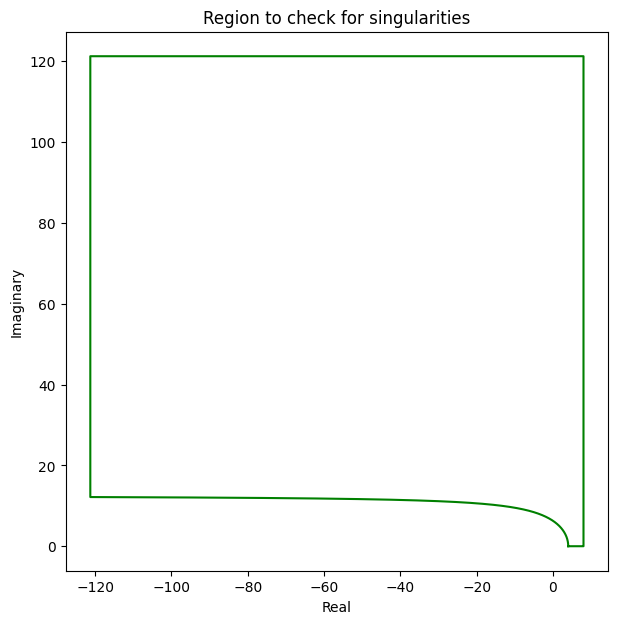

Evaluating F(z) along the closed bounding contour...


100%|██████████| 13996/13996 [1:01:51<00:00,  3.77it/s]


Calculating and unwrapping phase...

--- RESULTS ---
Numerical Closed-Loop Phase Shift: 0.0
SUCCESS: The phase shift is 0. All roots within the massive bounding box lie inside gamma.


In [13]:
# Create context
ctx = mpmath.mp
orig_dps = ctx.dps

# May need to be increased, when eps is small
ctx.dps = 100

# Generate curve
# 1. Setup parameters
eps = 0.1
N_gamma = int(1e4)
N_linear = int(1e3) # Points for each linear segment
r_val = 4

# Define Talbot contour function
def contour(theta, r=1):
    return r * theta * ctx.mpc(ctx.cot(theta), 1)

# Generate theta values for the Talbot curve (from 0 to pi-eps)
# This starts at r+0i and moves into the upper LHP
theta_values = ctx.linspace(1e-12, ctx.pi - eps, N_gamma)
path_gamma = [contour(t, r_val) for t in theta_values]
path_gamma[0] = ctx.mpc(r_val, 0)

# 2. Define the Linear Segments
# Point A: The end of the Talbot contour (-R + ih)
z_A = path_gamma[-1]
R_const = -z_A.real
h_const = z_A.imag

# Point B: Straight up to -R + iR
z_B = ctx.mpc(-R_const, R_const)

# Point C: Straight across to 2r + iR
z_C = ctx.mpc(2 * r_val, R_const)

# Point D: Straight down to 2r + 0i
z_D = ctx.mpc(2 * r_val, 0)

# Point E: Back to start (r + 0i)
z_E = ctx.mpc(r_val, 0)

# Helper to create linear paths
def get_line(start, end, N):
    return [start + (end - start) * t for t in ctx.linspace(0, 1, N)]

# 3. Combine paths
# Note: We slice [1:] to avoid duplicating the joint pixels
path_AB = get_line(z_A, z_B, N_linear)[1:]
path_BC = get_line(z_B, z_C, N_linear)[1:]
path_CD = get_line(z_C, z_D, N_linear)[1:]
path_DE = get_line(z_D, z_E, N_linear)[1:]

z_values = path_gamma + path_AB + path_BC + path_CD + path_DE

# Plot created path
plt.figure(figsize=(7, 7))
plt.plot([z.real for z in z_values], [z.imag for z in z_values], 'g-')
plt.xlabel("Real")
plt.ylabel("Imaginary")
plt.title("Region to check for singularities")
plt.show()

# Evaluate D(z)
def D(s):
    return c*s + c / zeta * s**2 - lmbda + lmbda * lapl_LN(s, ctx, mu_ln, sigma_ln)

print("Evaluating D(z) along the closed bounding contour...")
D_values = [D(z) for z in tqdm(z_values)]

# Calculate and unwrap phase
print("Calculating and unwrapping phase...")
atan_vals = [ctx.atan2(z.imag, z.real) for z in D_values]

def mpmath_unwrap(phases):
    unwrapped = [phases[0]]
    shift = ctx.mpf(0)
    pi_val = ctx.pi
    two_pi = 2 * pi_val

    for i in range(1, len(phases)):
        diff = phases[i] - phases[i-1]
        if diff < -pi_val:
            shift += two_pi
        elif diff > pi_val:
            shift -= two_pi
        unwrapped.append(phases[i] + shift)
    return unwrapped

unwrapped_phases = mpmath_unwrap(atan_vals)

# Check the Final Result
# For a closed loop, the total phase shift must be EXACTLY 0 to have 0 roots inside.
# (Note: due to computers being computers, it will be close to 0)
total_numerical_shift = unwrapped_phases[-1] - unwrapped_phases[0]
expected_shift = 0
error_tolerance = 1e-10

print("\n--- RESULTS ---")
print(f"Numerical Closed-Loop Phase Shift: {total_numerical_shift}")

if abs(total_numerical_shift - expected_shift) < error_tolerance:
    print("SUCCESS: The phase shift is 0. No roots within the region")
else:
    # If there are roots, the phase shift will be a multiple of 2*pi (e.g., -6.28, -12.56)
    roots_outside = round(float(abs(total_numerical_shift) / (2 * ctx.pi)))
    print(f"WARNING: Phase shifted! Detected approximately {roots_outside} root(s) OUTSIDE gamma in the bounding region.")

## Compute Probabilities

In [5]:
u_values = [0.1, 0.2, 0.3, 0.4, 0.5, 1, 2, 3, 4, 5, 10, 20]

approx = [talbot_method_abate(lapl_psi, u, M,
                              lmbda=lmbda,
                              q=q,
                              c=c,
                              zeta=zeta,
                              lapl_X_func=lapl_LN,
                              mu_N=mu_ln,
                              sigma_N=sigma_ln) for u in tqdm(u_values)]

approx_oscillation = [talbot_method_abate(lapl_psi_1, u, M,
                                          lmbda=lmbda,
                                          c=c,
                                          sigmasq=sigmasq,
                                          lapl_X_func=lapl_LN,
                                          mu_N=mu_ln,
                                          sigma_N=sigma_ln) for u in tqdm(u_values)]

approx_claim = [talbot_method_abate(lapl_psi_2, u, M,
                                    lmbda=lmbda,
                                    mu=mu,
                                    c=c,
                                    sigmasq=sigmasq,
                                    lapl_X_func=lapl_LN,
                                    mu_N=mu_ln,
                                    sigma_N=sigma_ln) for u in tqdm(u_values)]

100%|██████████| 12/12 [01:28<00:00,  7.40s/it]


## Display Results

In [6]:
print_results([u_values, approx, approx_oscillation, approx_claim],
              header="u\tApprox\t\tApprox (osc)\tApprox (claim)", num_digits=8)

u	Approx		Approx (osc)	Approx (claim)
0.1	0.72143034	0.37118594	0.35024439
0.2	0.61674776	0.14278848	0.47395928
0.3	0.57521322	0.05986819	0.51534503
0.4	0.55659996	0.029776834	0.52682312
0.5	0.54630603	0.018846967	0.52745906
1.0	0.51624497	0.012203463	0.50404151
2.0	0.46648468	0.010434432	0.45605025
3.0	0.42407972	0.0089090994	0.41517062
4.0	0.38763742	0.0077117188	0.3799257
5.0	0.35588773	0.0067616401	0.34912609
10.0	0.24235189	0.0039489978	0.23840289
20.0	0.12576221	0.0017429699	0.12401924


In [7]:
app_mix = [app1 + app2 for app1, app2 in zip(approx_oscillation, approx_claim)]
print_results([u_values, approx, app_mix], header="Checking that mix and direct yield similar results")

Checking that mix and direct yield similar results
0.1	0.7214303357	0.7214303357
0.2	0.6167477609	0.6167477609
0.3	0.5752132227	0.5752132227
0.4	0.5565999589	0.5565999589
0.5	0.5463060291	0.5463060291
1.0	0.5162449735	0.5162449735
2.0	0.4664846841	0.4664846841
3.0	0.4240797191	0.4240797191
4.0	0.3876374199	0.3876374199
5.0	0.3558877279	0.3558877279
10.0	0.2423518878	0.2423518878
20.0	0.1257622052	0.1257622052


## Justification for choise of $\alpha$ and cutoff

$\alpha$ governs the error in the approximation of $\mathcal{L}(f_X)$.
We choose $\alpha = 15$ to get approximately $\mathrm{e}^{-15} \approx 10^{-7}$.
The cut-off index has to be chosen large enough, such as to capture enough information to get an accurate approximation. To this end, we consider the convergence of the approximation of $\mathcal{L}(\psi)(r)$, which is the most important term.

100%|██████████| 80/80 [00:01<00:00, 73.84it/s]


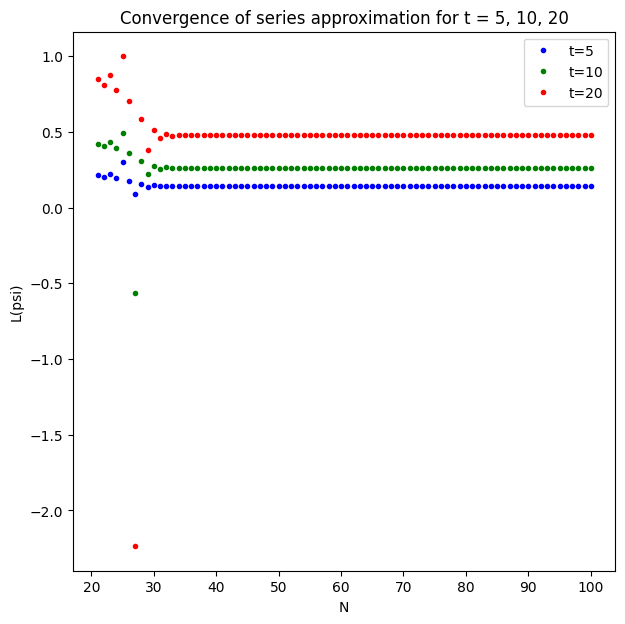

In [8]:
t = 10
r = ctx.fraction('2', '5') * M / t

# Consider cutoffs from 21 to 101
Ns = range(21, 101)
lapl_psi_values_10 = [lapl_psi(ctx.mpf(r), ctx, lmbda, q, c, zeta,
                               lapl_X_func=lapl_LN,
                               mu_N=mu_ln,
                               sigma_N=sigma_ln,
                               alpha=15,
                               maxSum=n) for n in tqdm(Ns)]

t = 5
r = ctx.fraction('2', '5') * M / t
lapl_psi_values_5 = [lapl_psi(ctx.mpf(r), ctx, lmbda, q, c, zeta,
                               lapl_X_func=lapl_LN,
                               mu_N=mu_ln,
                               sigma_N=sigma_ln,
                               alpha=15,
                               maxSum=n) for n in tqdm(Ns)]

t = 20
r = ctx.fraction('2', '5') * M / t
lapl_psi_values_20 = [lapl_psi(ctx.mpf(r), ctx, lmbda, q, c, zeta,
                               lapl_X_func=lapl_LN,
                               mu_N=mu_ln,
                               sigma_N=sigma_ln,
                               alpha=15,
                               maxSum=n) for n in tqdm(Ns)]

plt.figure(figsize=(7, 7))
plt.plot(Ns, [z.real for z in lapl_psi_values_5], 'b.', label="t=5")
plt.plot(Ns, [z.real for z in lapl_psi_values_10], 'g.', label="t=10")
plt.plot(Ns, [z.real for z in lapl_psi_values_20], 'r.', label="t=20")
plt.xlabel("N")
plt.ylabel("L(psi)")
plt.title("Convergence of series approximation for t = 5, 10, 20")
plt.legend()
plt.savefig("evolution_in_n.png")

In [9]:
t = 10
print(ctx.nstr(talbot_method_abate(lapl_psi, t, M, lmbda=lmbda,
                              q=q,
                              c=c,
                              zeta=zeta,
                              lapl_X_func=lapl_LN,
                              mu_N=mu_ln,
                              sigma_N=sigma_ln, alpha=15, maxSum=70), 15))
print(ctx.nstr(talbot_method_abate(lapl_psi, t, M, lmbda=lmbda,
                              q=q,
                              c=c,
                              zeta=zeta,
                              lapl_X_func=lapl_LN,
                              mu_N=mu_ln,
                              sigma_N=sigma_ln, alpha=20, maxSum=80), 15))
print(ctx.nstr(talbot_method_abate(lapl_psi, t, M, lmbda=lmbda,
                              q=q,
                              c=c,
                              zeta=zeta,
                              lapl_X_func=lapl_LN,
                              mu_N=mu_ln,
                              sigma_N=sigma_ln, alpha=25, maxSum=90), 15))
print(ctx.nstr(talbot_method_abate(lapl_psi, t, M, lmbda=lmbda,
                              q=q,
                              c=c,
                              zeta=zeta,
                              lapl_X_func=lapl_LN,
                              mu_N=mu_ln,
                              sigma_N=sigma_ln, alpha=30, maxSum=100), 15))

0.242351887823488
0.24235188782023
0.242351887820246
0.242351887820246
